# Exploring minima of Homsets

This notebook explores the distribution of minima of homsets of supersingular elliptic curves with scalar level structure. To run it you will need the following python packages:

In [1]:
import pandas as pd, numpy as np, gzip
from matplotlib import pyplot as plt
from scipy.stats import norm
import math

The dataset was pre-generated. To generate a new one, install Sagemath and then run

```
./sample_mt.py <how_many> -p<char> -g<mod>
```

This generates `<how_many>` random ideal classes of B_p,∞ with `p = <char>` and prints the 4 minima of the associated quadratic form, normalized by √p, and the associated Gram matrix modulo `<mod>`.

In [2]:
# parse the data into a Pandas dataframe
with gzip.open('p2e62_mega.csv.gz', 'rt') as f:
    # first line is a (useful) comment
    for i in range(1):
        print(next(f))
    idx = pd.MultiIndex.from_tuples([('λ', i) for i in range(4)] + [('g', r, c) for c in range(4) for r in range(c+1)],
                                    names=['type', 'row', 'col'])
    df = pd.read_csv(f, names=idx)

# ['./sample_mt.py', '1000000', '-p4611686018427388039', '-g2']



In [3]:
len(df)

1000000

## Odd elements in the lattice

We append the parity of the linear combinations of the basis vectors with coefficients in `[0,1]`

In [4]:
for i in range(1,16):
    lead = 3
    while not (1 << lead) & i:
        lead -= 1
    df[('parity', i, 0)] = df.g[lead][lead]
    low = i - (1 << lead)
    if low:
        df[('parity', i, 0)] += df[('parity', low, 0)]
        row = lead - 1
        while row >= 0:
            if (1 << row) & i:
                df[('parity', i, 0)] += df.g[row][lead]
            row -= 1
        df[('parity', i, 0)] %= 2

And then we count the ratio of odd elements in the box generated by the first 1, 2, 3, 4 minima

In [5]:
for i in range(1,5):
    df[('cum', i, 0)] = sum(df[('parity', x, 0)] for x in range(1, 1 << i)) / (1 << i)

Histograms confirm the predicted densities. Starting from the 3rd minimum, there is always at least 25% of odd elements.

array([[<Axes: title={'center': '(1, 0.0)'}>,
        <Axes: title={'center': '(2, 0.0)'}>],
       [<Axes: title={'center': '(3, 0.0)'}>,
        <Axes: title={'center': '(4, 0.0)'}>]], dtype=object)

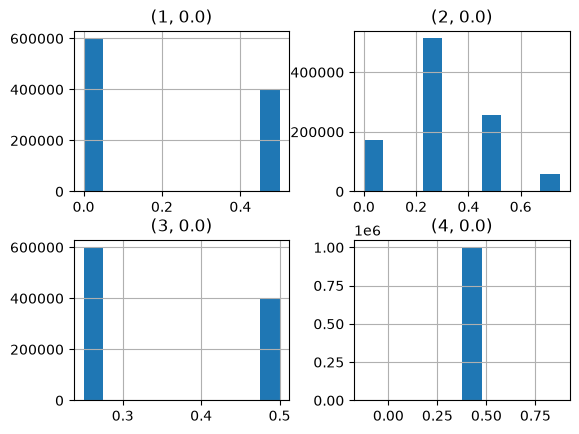

In [6]:
df.cum.hist()

## The minima

Remember everything is divided by √p

In [7]:
df.λ.describe()

,0,1,2,3
,NaN,NaN,NaN,NaN
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,0.263063,0.455550,0.718418,1.512002
std,0.117371,0.143143,0.288279,2.618435
min,0.000153,0.008308,0.060349,0.519259
25%,0.173351,0.364778,0.566573,0.841080
50%,0.260966,0.454268,0.655895,1.080021
75%,0.349756,0.535759,0.792351,1.556371
max,0.629166,4.174426,37.002838,1308.483446


1st and 4th minimum compared, log scale

<Axes: >

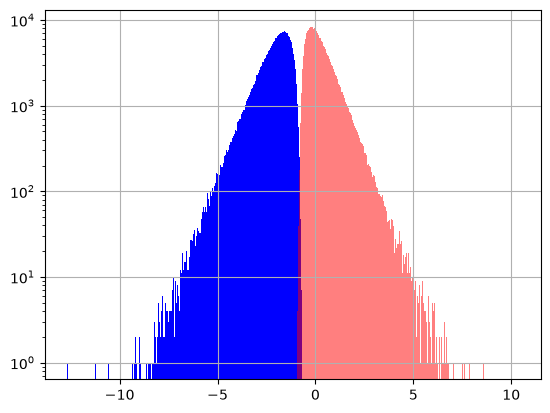

In [8]:
np.log2(df[('λ', 0, None)]).hist(bins=1000, color='blue', log=True)
np.log2((df[('λ', 3, None)])).hist(bins=1000, color='red', alpha=0.5, log=True)

2nd and 3rd

<Axes: >

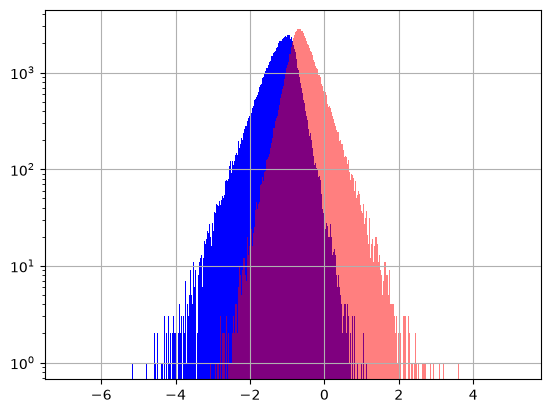

In [9]:
np.log2(df[('λ', 1, None)]).hist(bins=4000, color='blue', log=True)
np.log2(df[('λ', 2, None)]).hist(bins=4000, color='red', alpha=0.5, log=True)

Analyzing the quantiles in geometric progressoin (ratio 2) reveals a decently stable geometric progressions in the minima (`pct_change()` computes the "economist's ratio" between a row and its predecessor, so ratio is `1 + pct_change`)

In [10]:
df.λ.quantile([1-1/2**i for i in range(1,21)])

,0,1,2,3
,NaN,NaN,NaN,NaN
0.500000,0.260966,0.454268,0.655895,1.080021
0.750000,0.349756,0.535759,0.792351,1.556371
0.875000,0.407446,0.594350,0.947610,2.197777
0.937500,0.448542,0.656909,1.128095,3.088033
0.968750,0.479362,0.729216,1.343750,4.332601
0.984375,0.503490,0.814200,1.595118,6.093604
0.992188,0.522790,0.909053,1.899807,8.614093
0.996094,0.538565,1.014931,2.252382,12.096468
0.998047,0.552072,1.137701,2.656238,17.355379


In [11]:
df.λ.quantile([1-1/2**i for i in range(1,21)]).pct_change()

,0,1,2,3
,NaN,NaN,NaN,NaN
0.500000,NaN,NaN,NaN,NaN
0.750000,0.340238,0.179390,0.208046,0.441056
0.875000,0.164944,0.109360,0.195947,0.412116
0.937500,0.100862,0.105257,0.190464,0.405071
0.968750,0.068711,0.110072,0.191167,0.403030
0.984375,0.050333,0.116542,0.187065,0.406454
0.992188,0.038334,0.116498,0.191014,0.413629
0.996094,0.030174,0.116471,0.185585,0.404265
0.998047,0.025080,0.120964,0.179301,0.434748


By the eye test, $Pr(λ₃ > 2^{x/4} · m₃) < 1/2^{(x+1)}$, with $m$ being the median, looks like a pretty decent predictor

In [12]:
m = df.λ[2][np.nan].median()
[(len(df[df[('λ',2,None)] > m * np.sqrt(np.sqrt(2))**x]) / len(df) * 2**(x+1)) for x in range(0, 20)]

[1.0,
 1.062636,
 1.088216,
 1.093552,
 1.099232,
 1.094592,
 1.104256,
 1.075968,
 1.053696,
 1.037312,
 0.968704,
 0.999424,
 0.950272,
 0.851968,
 0.884736,
 0.786432,
 1.048576,
 1.31072,
 1.048576,
 2.097152]

### Hill estimator

To argue about the correctness of the proposed hypotesis we cosider the [Hill estimator](https://en.wikipedia.org/wiki/Heavy-tailed_distribution#Hill.27s_tail-index_estimator), designed to estimate the behaviour of distributions with heavy upper tails. We search for $\alpha$ and $C$ such that
$$ \mathbb P(X > x) = \bar F(x) \sim C x^{-\alpha} $$
for large $x$, with $\alpha > 0$. Note: in the extreme value theory usually they write instead using $ \gamma = \frac{1}{\alpha}$.

#### Definition

Consider the order statistics of the sample
$$
X_{(1)} \le X_{(2)} \le \cdots \le X_{(n)}
$$

(funny word to say we use the sorted observations).
Choose a tail size $k$, meaning that only the largest $k$ observations are used. The threshold is

$$
u = X_{(n-k)}.
$$

The Hill estimate of $\gamma = 1/\alpha$ is

$$
\hat\gamma(k)
= \frac{1}{k} \sum_{i=1}^k
\log\left(\frac{X_{(n-i+1)}}{u}\right).
$$

Then

$$
\hat\alpha(k) = \frac{1}{\hat\gamma(k)}.
$$

If the upper tail is close to Pareto with exponent $\alpha$, then $\hat\alpha(k)$ should be stable near $\alpha$ for a reasonable range of intermediate values of $k$.

#### Choice of k

The parameter $k$ is the main tuning choice.

- If $k$ is too small, the estimate uses very few points and has high variance.
- If $k$ is too large, the estimate includes non-tail observations and becomes biased.
- The usual diagnostic is a Hill plot: plot $\hat\alpha(k)$ against $k$ and look for a stable plateau.

From the theory (Theorem 3.2.2 of de Haan, Ferreira) we should choose $k$ as a function of the sample size $n$ so that as $n \to \infty$
- $k(n) \to \infty$
- $k(n)/n \to 0$ .

In practice, we have a fixed sample size $n$, so we look for a range of $k$ that is not too small and not too large.

For our data, good diagnostics were obtained for values such that $k/n$ ranges between about $0.01 \%$ and $1 \%$ of the sample size (`n > 1e6`).
For larger k they started to behave differently, likely because it includes too much of the non-tail part of the distribution.

#### Confidence Intervals

Under standard regular variation assumptions, the Hill estimator has an asymptotic normal approximation. For $\hat\alpha$, a rough standard error is

$$ \operatorname{se}(\hat\alpha) \approx \frac{\hat\alpha}{\sqrt{k}}. $$

Thus an approximate 95% confidence interval is

$$ \hat\alpha \pm 1.96 \frac{\hat\alpha}{\sqrt{k}}. $$

This interval should be treated as a diagnostic, not as a final rigorous theorem for the finite-support distribution. It is useful because the finite cutoff is far outside the sampled range.

#### Testing $\alpha = 4$

For the null hypothesis

$$
H_0: \alpha = 4,
$$

we use

$$ z = \frac{\hat\alpha - 4}{4 / \sqrt{k}}. $$

The two-sided p-value is

$$
p = 2 \left(1 - \Phi(|z|)\right).
$$

This is again an asymptotic diagnostic. In our data, the p-values for $k$ between about $500$ and $20000$ did not reject $\alpha = 4$, while very large $k$ was less reliable.

#### Estimating C

If we fix $\alpha = 4$, then at the threshold $u = X_{(n-k)}$ we have

$$
\mathbb P(X > u) \approx \frac{k}{n}
$$

and the model says

$$
\mathbb P(X > u) \approx \frac{C}{u^4}.
$$

Therefore

$$
\hat C(k) = \frac{k}{n} u^4.
$$

If the model $\mathbb P(X > x) \sim C/x^4$ is valid over the observed tail range, then $\hat C(k)$ should also be reasonably stable as a function of $k$.


In [13]:
d = np.sort(df[('λ', 2, None)].dropna().to_numpy()) 
n = len(d) 
alpha0 = 4 
rows = [] 
perc_span = np.linspace(0.001, 0.1, 100) 

for perc in perc_span:
    k = math.ceil(perc*n)
    u = d[-k-1]
    tail = d[-k:]
    gamma_hat = np.mean(np.log(tail / u))
    alpha_hat = 1 / gamma_hat
    
    se = alpha_hat / math.sqrt(k)
    
    # Test H0: alpha = 4 using the Hill asymptotic normal approximation
    se0 = alpha0 / math.sqrt(k)
    z = (alpha_hat - alpha0) / se0
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    rows.append({
        "k": k,
        "perc": perc,
        "threshold": u,
        "alpha_hat": alpha_hat,
        "ci_low": alpha_hat - 1.96 * se,
        "ci_high": alpha_hat + 1.96 * se,
        "z_alpha_eq_alpha0": z,
        "p_value_alpha_eq_alpha0": p_value,
        "C_hat_alpha0": (k / n) * u**4,
    })

out = pd.DataFrame(rows)
out


,k,perc,threshold,alpha_hat,ci_low,ci_high,z_alpha_eq_alpha0,p_value_alpha_eq_alpha0,C_hat_alpha0
0,1000,0.001,3.125751,4.160146,3.902297,4.417994,1.266063,0.205490,0.095459
1,2000,0.002,2.640917,4.126280,3.945438,4.307122,1.411855,0.157993,0.097286
2,3000,0.003,2.403368,4.183169,4.033477,4.332862,2.508151,0.012136,0.100093
3,4000,0.004,2.235620,4.129237,4.001270,4.257203,2.043410,0.041012,0.099920
4,5000,0.005,2.118853,4.136799,4.022133,4.251465,2.418291,0.015594,0.100780
...,...,...,...,...,...,...,...,...,...
95,96000,0.096,1.013190,4.000109,3.974805,4.025414,0.008479,0.993235,0.101166
96,97000,0.097,1.010658,4.001508,3.976325,4.026690,0.117388,0.906553,0.101202
97,98000,0.098,1.008126,4.002383,3.977324,4.027442,0.186499,0.852053,0.101224
98,99000,0.099,1.005481,4.000941,3.976018,4.025864,0.074051,0.940970,0.101188


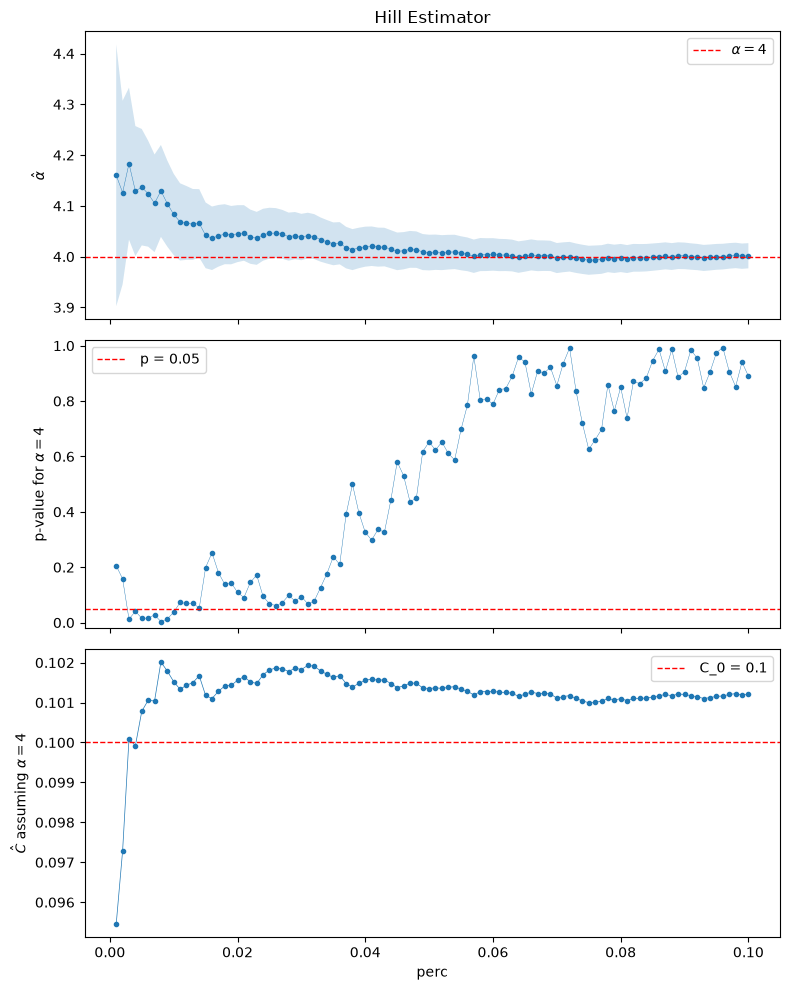

In [14]:

title = 'Hill Estimator'
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax = axes[0]
ax.plot(out["perc"], out["alpha_hat"], marker=".", linewidth=0.3)
ax.fill_between(out["perc"], out["ci_low"], out["ci_high"], alpha=0.2)
ax.axhline(alpha0, color="red", linestyle="--", linewidth=1, label=fr"$\alpha={alpha0}$")
ax.set_ylabel(r"$\hat\alpha$")
ax.set_title(title or "Hill tail diagnostics")
ax.legend()

ax = axes[1]
ax.plot(out["perc"], out["p_value_alpha_eq_alpha0"], marker=".", linewidth=0.3)
p = 0.05
ax.axhline(p, color="red", linestyle="--", linewidth=1, label=f"{ p = }")
ax.set_ylabel(fr"p-value for $\alpha={alpha0}$")
ax.set_ylim(-0.02, 1.02)
ax.legend()

ax = axes[2]
ax.plot(out["perc"], out["C_hat_alpha0"], marker=".", linewidth=0.5)
C_0 = 0.1
ax.axhline(C_0, color="red", linestyle="--", linewidth=1, label=f"{ C_0 = }")
ax.set_ylabel(fr"$\hat C$ assuming $\alpha={alpha0}$")
ax.set_xlabel("perc")
ax.legend()

plt.tight_layout()
plt.show()


We can run the same test for $\lambda_4$ with $\alpha_0 = 2$. The estimator seems to suggest that instead $\alpha \geq 2$.

In [20]:
d = np.sort(df[('λ', 3, None)].dropna().to_numpy()) 
n = len(d) 
alpha0 = 2
rows = [] 
perc_span = np.linspace(0.001, 0.3, 100) 

for perc in perc_span:
    k = math.ceil(perc*n)
    u = d[-k-1]
    tail = d[-k:]
    gamma_hat = np.mean(np.log(tail / u))
    alpha_hat = 1 / gamma_hat
    
    se = alpha_hat / math.sqrt(k)
    
    # Test H0: alpha = 4 using the Hill asymptotic normal approximation
    se0 = alpha0 / math.sqrt(k)
    z = (alpha_hat - alpha0) / se0
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    rows.append({
        "k": k,
        "perc": perc,
        "threshold": u,
        "alpha_hat": alpha_hat,
        "ci_low": alpha_hat - 1.96 * se,
        "ci_high": alpha_hat + 1.96 * se,
        "z_alpha_eq_alpha0": z,
        "p_value_alpha_eq_alpha0": p_value,
        "C_hat_alpha0": (k / n) * u**4,
    })

out = pd.DataFrame(rows)
out


,k,perc,threshold,alpha_hat,ci_low,ci_high,z_alpha_eq_alpha0,p_value_alpha_eq_alpha0,C_hat_alpha0
0,1000,0.001000,23.928167,1.994823,1.871183,2.118463,-0.081855,0.934762,327.821731
1,4021,0.004020,11.930487,1.975907,1.914833,2.036981,-0.763883,0.444937,81.464205
2,7041,0.007040,9.058911,2.000141,1.953421,2.046860,0.005907,0.995287,47.417462
3,10061,0.010061,7.586020,2.001554,1.962443,2.040665,0.077934,0.937880,33.319387
4,13081,0.013081,6.661868,2.006954,1.972560,2.041347,0.397655,0.690885,25.764693
...,...,...,...,...,...,...,...,...,...
95,287920,0.287919,1.447932,2.011675,2.004327,2.019023,3.132384,0.001734,1.265507
96,290940,0.290939,1.440055,2.010597,2.003291,2.017903,2.857897,0.004265,1.251180
97,293960,0.293960,1.432466,2.010003,2.002737,2.017269,2.711733,0.006693,1.237730
98,296980,0.296980,1.425259,2.010167,2.002937,2.017397,2.770364,0.005599,1.225468


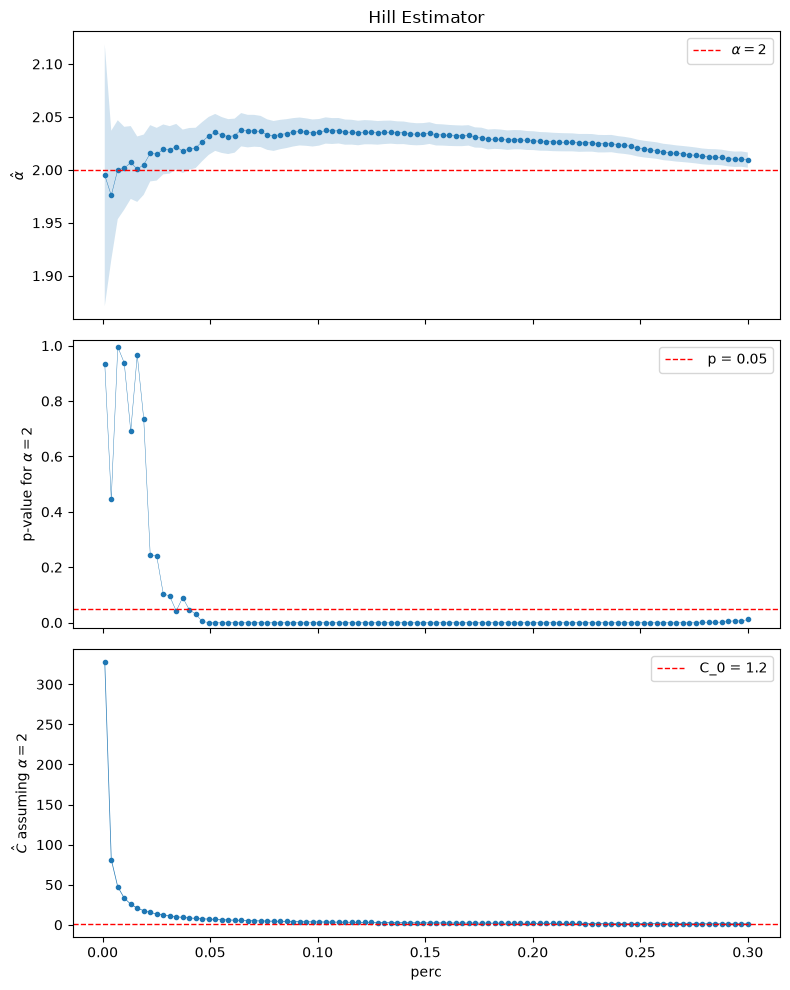

In [21]:

title = 'Hill Estimator'
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax = axes[0]
ax.plot(out["perc"], out["alpha_hat"], marker=".", linewidth=0.3)
ax.fill_between(out["perc"], out["ci_low"], out["ci_high"], alpha=0.2)
ax.axhline(alpha0, color="red", linestyle="--", linewidth=1, label=fr"$\alpha={alpha0}$")
ax.set_ylabel(r"$\hat\alpha$")
ax.set_title(title or "Hill tail diagnostics")
ax.legend()

ax = axes[1]
ax.plot(out["perc"], out["p_value_alpha_eq_alpha0"], marker=".", linewidth=0.3)
p = 0.05
ax.axhline(p, color="red", linestyle="--", linewidth=1, label=f"{ p = }")
ax.set_ylabel(fr"p-value for $\alpha={alpha0}$")
ax.set_ylim(-0.02, 1.02)
ax.legend()

ax = axes[2]
ax.plot(out["perc"], out["C_hat_alpha0"], marker=".", linewidth=0.5)
C_0 = 1.2
ax.axhline(C_0, color="red", linestyle="--", linewidth=1, label=f"{ C_0 = }")
ax.set_ylabel(fr"$\hat C$ assuming $\alpha={alpha0}$")
ax.set_xlabel("perc")
ax.legend()

plt.tight_layout()
plt.show()
